# Exploratory Data Analysis: EDA

## 1. PCA on Population Arrays: Try different time bins and stimulus bins

Start by running PCA on different populations arrays, different time bins and stimulus conditions. We can take a look at projection of the data onto the first 2 arrays and the variance explained by the PCs to see if any natural clusters arise.

Choices: 
The feature vetors (neurons) are centered to have mean 0, (subtract mean firing rate) and are not normalized. 



In [2]:
% load data
addpath('matlab','data')
load('calcium_data.mat')
load('stimuli_info.mat')
load ('data_stimsorted.mat')

In [3]:
%Variables
thrld = 0.25;
fov = 3; % 1 of 8 FOV
tbin = 1; % 1 second time bin
stimulus = {'e3', 'e2', 'e1', 'd3', 'd2', 'd1', 'c3', 'c2', 'c1', 'blank'};
stim_onset = 5;

## 1.a PCA Spontaneous Data: $t_\rm{bin}=1s$ and $t_\rm{bin}=500ms$

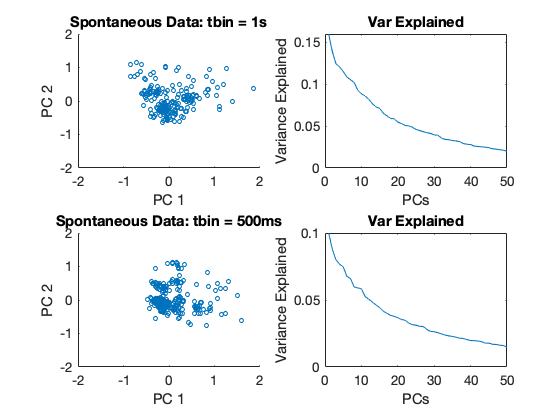

In [374]:
% Sponataneous Data - tbin = 1s
events_spont1 = get_spikes_spont(dat_sorted,fov,1,thrld);

%Run PCA - tbin = 1s
[PCA_spont.tbin1.coeff,PCA_spont.tbin1.score,PCA_spont.tbin1.latent] = pca(events_spont1.', 'Centered', true);
subplot(2,2,1)
scatter(PCA_spont.tbin1.score(:,1), PCA_spont.tbin1.score(:,2),10)% projection onto first 2 components
xlim([-2,2])
ylim([-2,2])
xlabel('PC 1')
ylabel('PC 2')
title('Spontaneous Data: tbin = 1s')
subplot(2,2,2)
plot_varexplained(PCA_spont.tbin1.latent); % variance explained

% Sponataneous Data - tbin = 500 ms
events_spont500 = get_spikes_spont(dat_sorted,fov,0.5,thrld);

%Run PCA
[PCA_spont.tbin05.coeff,PCA_spont.tbin05.score,PCA_spont.tbin05.latent] = pca(events_spont500.', 'Centered', true);
subplot(2,2,3)
scatter(PCA_spont.tbin05.score(:,1), PCA_spont.tbin05.score(:,2),10)% projection onto first 2 components
xlim([-2,2])
ylim([-2,2])
xlabel('PC 1')
ylabel('PC 2')
title('Spontaneous Data: tbin = 500ms')
subplot(2,2,4)
plot_varexplained(PCA_spont.tbin05.latent); % variance explained

No clear structure, and variance explained is low for first few PCs. Can try to project the spontaneous data on the PCs found using the stimulus data afterward.

## 1.b PCA Stimulus Data: $t_\rm{bin}=1s$

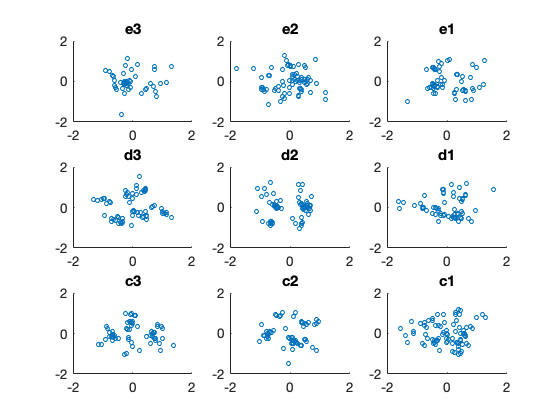

In [375]:
% Individual Whisker Stimulations: 1000 ms after stimulus onset
tbin = 1;% seconds
for stim_num = 1:length(stimulus)-1
    events_stim = get_spikes_stim(dat_sorted,fov,thrld,stim_onset,tbin,stim_num);

    %Run PCA
    [coeff,score,latent] = pca(events_stim.', 'Centered', true);
    subplot(3,3,stim_num)
    scatter(score(:,1), score(:,2),10)% projection onto first 2 components
    xlim([-2,2])
    ylim([-2,2])
    title(stimulus{stim_num})
end

## 1.c PCA Stimulus Data: $t_\rm{bin}=500 ms$

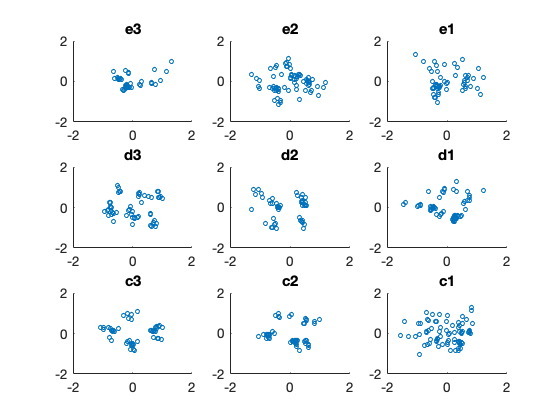

In [376]:
% Individual Whisker Stimulations: 500 ms after stimulus onset
tbin = 0.5;% seconds
for stim_num = 1:length(stimulus)-1
    events_stim = get_spikes_stim(dat_sorted,fov,thrld,stim_onset,tbin,stim_num);

    %Run PCA
    [PCA_stim.(stimulus{stim_num}).coeff,PCA_stim.(stimulus{stim_num}).score,PCA_stim.(stimulus{stim_num}).latent] = pca(events_stim.', 'Centered', true);
    subplot(3,3,stim_num)
    scatter(PCA_stim.(stimulus{stim_num}).score(:,1), PCA_stim.(stimulus{stim_num}).score(:,2),10)% projection onto first 2 components
    xlim([-2,2])
    ylim([-2,2])
    title(stimulus{stim_num})
end

Reducing the time bin to $t_\rm{bin} = 500 ms$ sharpens the cluster boundaries when the data is projected on the first 2 PCs. This is particularly true for whiskers d2, c3 and c2.

## 1.d PCA All Whisker Data: $t_\rm{bin}=500 ms$ - Include 1000 ms after stimulus onset

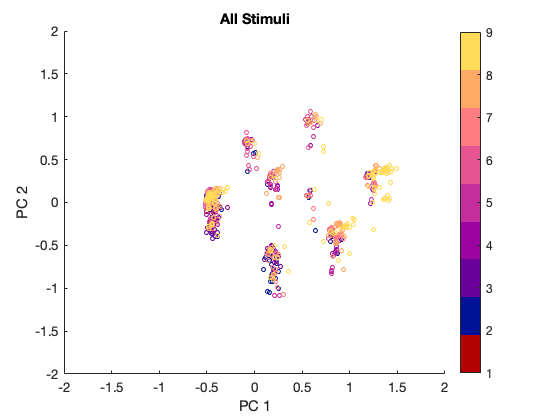

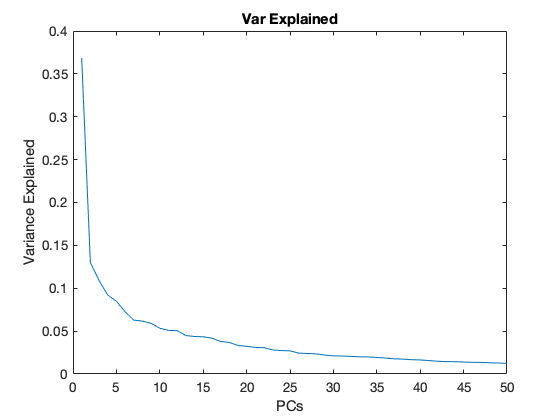

In [377]:
% All Whisker Stimulations: 500 ms after stimulus onset
tbin=0.5;
events_all2=[];
stim_label2 = [];
for stim_num = 1:length(stimulus)-1
    events_stim = get_spikes_stim2(dat_sorted,fov,thrld,tbin,stim_num);
    events_all2 = cat(2,events_all2, events_stim);
    stim_label2 = cat(1,stim_label2,ones(size(events_stim,2),1)*stim_num);
end

[PCA_allstim.coeff,PCA_allstim.score,PCA_allstim.latent] = pca(events_all2.', 'Centered', true);
plot_PCA(PCA_allstim.score, stim_label2, 'All Stimuli')

figure(2)
plot_varexplained(PCA_allstim.latent);
% scatter3(PCA_allstim.score(:,1), PCA_allstim.score(:,2),PCA_allstim.score(:,3),10, stim_label)

Including the 2nd bin after stimulus onset in the ensemble detection deteriortes cluster seperability and increases spread. Just use the first 500 ms to determine the ensembles.


## 1.e PCA All Whisker Data: $t_\rm{bin}=500 ms$

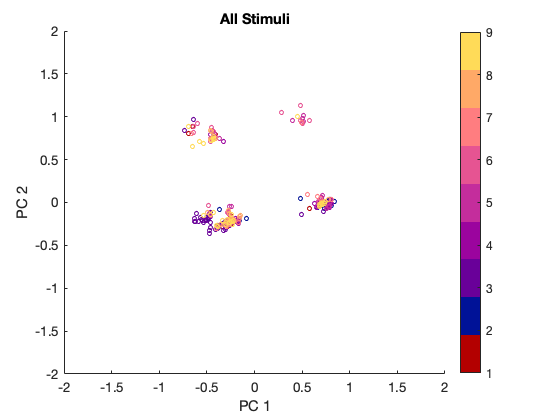

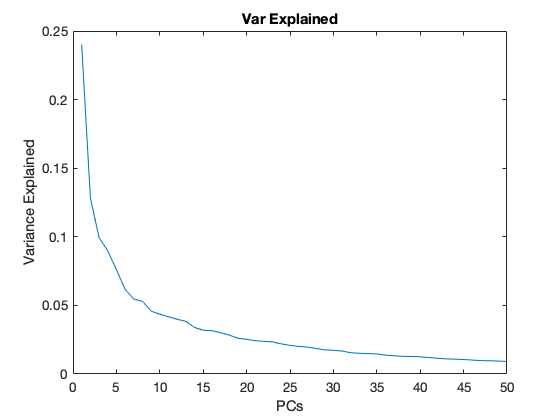

In [4]:
% All Whisker Stimulations: 500 ms after stimulus onset
tbin=0.5;
events_all=[];
stim_label = [];
for stim_num = 1:length(stimulus)-1
    events_stim = get_spikes_stim(dat_sorted,fov,thrld,stim_onset,tbin,stim_num);
    events_all = cat(2,events_all, events_stim);
    stim_label = cat(1,stim_label,ones(size(events_stim,2),1)*stim_num);
end

[PCA_allstim.coeff,PCA_allstim.score,PCA_allstim.latent] = pca(events_all.', 'Centered', true);
plot_PCA(PCA_allstim.score, stim_label, 'All Stimuli')

figure(2)
plot_varexplained(PCA_allstim.latent);
% scatter3(PCA_allstim.score(:,1), PCA_allstim.score(:,2),PCA_allstim.score(:,3),10, stim_label)

Variance Explained is much higher when all 9 whisker stimulus conditions are taken together. 8 clearly formed clusters arise and they whisker stimulations are intermixed

## 2. Project Spontaneous Population Array (PA) using PCs derived using Stimulus PA

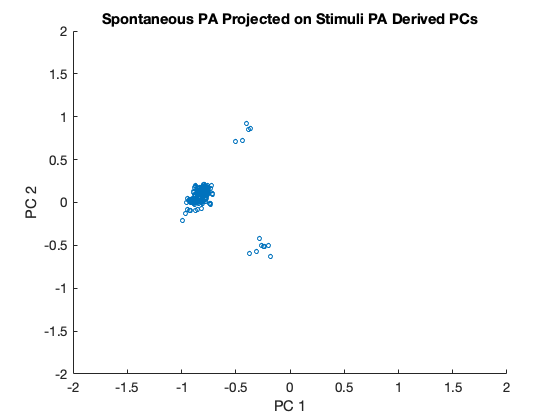

In [379]:
%Center and Project Data
[~, mu, sig] = zscore(events_all.');
spont_centered = events_spont500.' - mu;
score_spont = spont_centered*PCA_allstim.coeff;

%Plot
scatter(score_spont(:,1), score_spont(:,2),10)
xlim([-2,2])
ylim([-2,2])
xlabel('PC 1')
ylabel('PC 2')
title('Spontaneous PA Projected on Stimuli PA Derived PCs')

There is a resemblance to 3 of the clusters that are present when the stimulus data is projected.

## 3. Try k-means to determine clusters

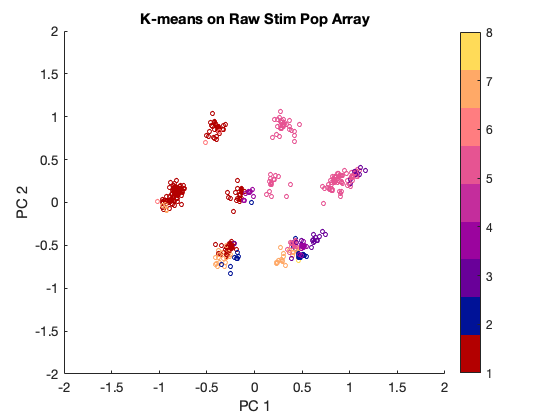

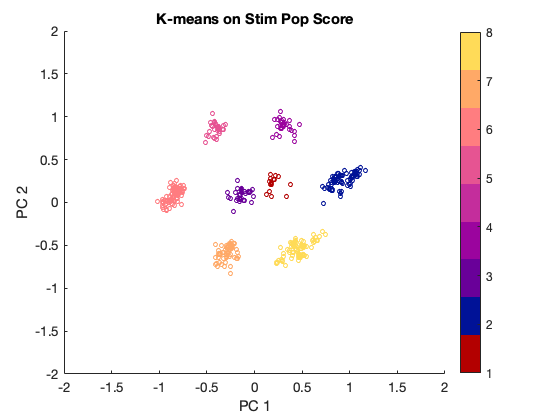

In [404]:
% K-means on Raw Data 
cluster_num = 8;
[cluster_lbls_raw,centroid_locs_raw,sumd_raw] = kmeans(events_all.',cluster_num, 'Distance', 'cityblock');
plot_PCA(PCA_allstim.score, cluster_lbls_raw, 'K-means on Raw Stim Pop Array')

%K-means on PC Data
figure(2)
[cluster_lbls,centroid_locs,sumd] = kmeans(PCA_allstim.score(:,1:2),cluster_num, 'Distance', 'sqeuclidean');
plot_PCA(PCA_allstim.score, cluster_lbls, 'K-means on Stim Pop Score')


## 4. Other Methods: Weighted PCA

Next we try performing a weighted PCA using the all_stim population array. Taking a look at the variance across the different ROIS, we notice some are essentialy 0 and do not contribute.

Using a weighted PCA could help reduce their contribution to determining the PCs. The default weights used in matlab are the inverse variance of X so we will try using the default and the variance 

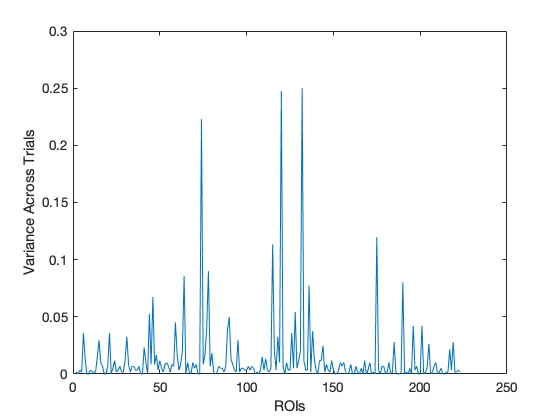

In [381]:
% Take a look at ROI variances across trials
plot(var(events_all.'))
xlabel('ROIs')
ylabel('Variance Across Trials')

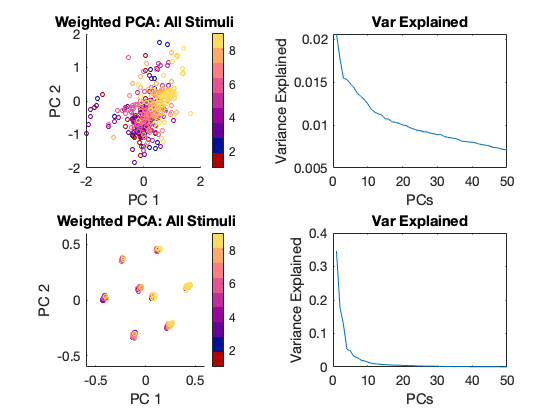

In [382]:
%inverse variance weight - matlab default
wt=1./var(events_all.');
wt(wt==inf) = 10^4; % make infinities large numbers
% wt = wt/sum(wt); % try normalizing, doesn't work

%variance weight 
wt1 = var(events_all.');
% wt1 = wt1/sum(wt1); % try normalizing, doesn't work
wt1(wt1==0) = 0.001; % make zero really small 
   
[winv_coeff,winv_score,w_invlatent] = pca(events_all.', 'Centered', true, 'VariableWeights', wt);
[wcoeff,wscore,wlatent] = pca(events_all.', 'Centered', true, 'VariableWeights', wt1);
subplot(2,2,1)
plot_PCA(winv_score, stim_label, 'Weighted PCA: All Stimuli')
subplot(2,2,2)
plot_varexplained(w_invlatent/sum(w_invlatent))
subplot(2,2,3)
plot_PCA(wscore, stim_label, 'Weighted PCA: All Stimuli')
xlim([-0.6,0.6])
ylim([-0.6,0.6])
subplot(2,2,4)
plot_varexplained(wlatent/sum(wlatent))


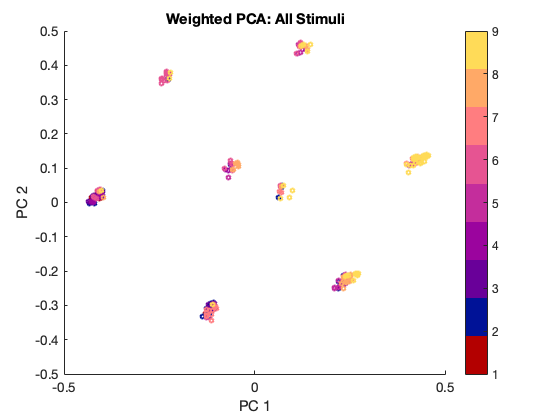

In [409]:
plot_PCA(wscore, stim_label, 'Weighted PCA: All Stimuli')
ylim([-0.5,0.5])
xlim([-0.5,0.5])

A weighted PCA improves cluster distance and radius, resultuing in tighter well seperated ensembles. The first 10 PCs explain 80% of the variance. 

_Note_: the coefficient matrix wcoeff is not orthonormal, to make it orthonormal `events_all` needs to be invertible and its not in this case because of the zero entries. Try changing 0 -> 0.00001

In [383]:
% Try converting wcoeffs to orthonormal basis
events_all(events_all == 0) = 0.0001;% make events_all invertible
wcoeff_orth = diag(std(events_all.'))\wcoeff;

Making the 0s small ended up making coefficients large after inversion. Try using weighted coefficients, check if orthogonal first.

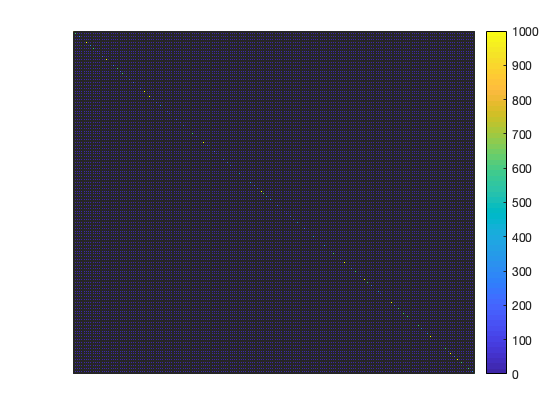

In [384]:
%Check the orthgonality of wcoeff
heatmap(wcoeff*wcoeff');
colormap default
Ax = gca;
Ax.XDisplayLabels = nan(size(Ax.XDisplayData));
Ax.YDisplayLabels = nan(size(Ax.YDisplayData));

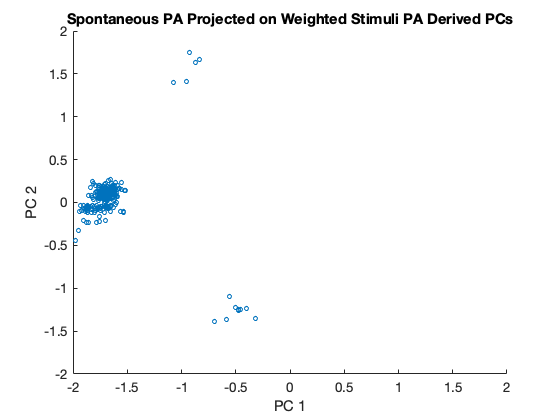

In [385]:
% project spontaneous Population Array (PA) onto non-orthonormal PCs found using stimulus PA
score_spont = spont_centered*wcoeff;

scatter(score_spont(:,1), score_spont(:,2),10)
xlim([-2,2])
ylim([-2,2])
xlabel('PC 1')
ylabel('PC 2')
title('Spontaneous PA Projected on Weighted Stimuli PA Derived PCs')

Although the coefficients are not normalized, there is a resemblance to 3 of the clusters that are present when the stimulus data is projected.

Looks similar to previous plot using unweighted PCs. Need to find figure out a solution to normalization problem if weighted PCA is used in the future. 

To DO 
_Regular PCA_
- try plotting loads
_Other Methods_
- read about other PCA methods
- ICA, sparse coding 
- NMF and staNMF
- CRF Yuste Method